# EU G4 Inflation-at-Risk (IaR)

**Macro-financial risk framework for EU G4 (France, Germany, Italy, Spain)**  
Applies the Machado–Santos Silva (2019) location-scale quantile regression approach  
to quantify the conditional distribution of future HICP inflation.

---

### Methodology brief

| Step | Description |
|------|-------------|
| 1 | Pull 8 conditioning series for 29 EU/EEA countries (1999–2025) |
| 2 | MSS location-scale quantile regression, horizons h ∈ {1, 2, 4} |
| 3 | Fit Fernández-Steel skewed-t to P5/P25/P50/P75/P95 quantile predictions |
| 4 | Log-score density pooling across horizons (Crump *et al.* 2022) |
| 5 | Extract IaR P95; re-centre to ECB/AMECO 2027 country baselines |
| 6 | Panel logit de-anchoring early-warning signal (HICP > 3% × 2 yr) |

*References: López-Salido & Loria (2024) JME · Korobilis et al. (2021) ECB WP 2591 · Banerjee et al. (2024) JIMF*

In [66]:
import sys, os, warnings, importlib
warnings.filterwarnings('ignore')

# Make sure the project root is on the path
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')  # safe for notebooks too
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image, display, Markdown

pd.options.display.float_format = '{:.4f}'.format
print('Environment ready.')

Environment ready.


---
## Phase 1 — Data Pipeline
Fetch / load all eight conditioning series, then merge into a balanced panel.

In [67]:
from data.hicp import load_hicp
from data.ameco import load_ameco
from data.output_gap import load_output_gap
from data.energy_prices import load_energy_prices
from data.import_prices import load_import_prices
from data.imf_fsi import load_fsi
from data.ecb_spreads import load_spreads
from data.wui import load_wui

print('Loading HICP (Eurostat) …')
hicp_df = load_hicp()

print('Loading AMECO inflation expectations …')
ameco_df = load_ameco()

print('Loading OECD output gap …')
ogap_df = load_output_gap()

print('Loading Brent energy prices (FRED) …')
energy_df = load_energy_prices()

print('Loading import prices …')
import_df = load_import_prices()

print('Loading ECB CLIFS financial stress …')
fsi_df = load_fsi()

print('Loading Eurostat 10Y bond spreads …')
spreads_df = load_spreads()

print('Loading World Uncertainty Index …')
wui_df = load_wui()

print('\nAll series loaded.')

Loading HICP (Eurostat) …
Loading AMECO inflation expectations …
Loading OECD output gap …
Loading Brent energy prices (FRED) …
Loading import prices …
Loading ECB CLIFS financial stress …
Loading Eurostat 10Y bond spreads …
Loading World Uncertainty Index …

All series loaded.


In [68]:
from data.panel_builder import build_panel

panel = build_panel()

print(f'Panel shape: {panel.shape}')
print(f'Countries: {panel["iso3"].nunique()}')
print(f'Year range: {panel["year"].min()} – {panel["year"].max()}')
panel.tail(8)

Building IaR estimation panel …

Panel: 804 rows × 14 cols
Countries: 29
Year range: 1999–2026

Non-null counts per variable:
  hicp_lag                 :   775
  output_gap               :   762
  infl_expectations        :   804
  energy_price_chg         :   804
  import_price_chg         :   804
  clifs                    :   718
  spread_10y               :   723
  wui                      :   668

Saved → /workspaces/inflation_at_risk/data/panel.parquet
Panel shape: (804, 14)
Countries: 29
Year range: 1999 – 2026


,iso3,year,hicp,output_gap,infl_expectations,energy_price_chg,import_price_chg,clifs,spread_10y,wui,hicp_lag,hicp_fwd1,hicp_fwd2,hicp_fwd4
796,SWE,2019,1.7250,1.1259,1.7842,-9.8600,-2.9500,0.0908,0.2933,0.1165,2.0500,0.6583,1.6542,4.3312
797,SWE,2020,0.6583,-2.6281,0.4974,-34.7500,-8.4625,0.1126,0.4733,0.3769,1.7250,2.6500,5.3417,4.6667
798,SWE,2021,2.6500,0.5568,2.1632,68.8800,11.7250,0.0395,0.6417,0.0838,0.6583,8.0333,7.0083,4.6562
799,SWE,2022,8.0333,0.1101,8.3693,42.4500,22.3500,0.2447,0.3900,0.2406,2.6500,5.9833,3.9917,3.1104
800,SWE,2023,5.9833,-1.6081,8.5486,-18.2700,-8.2625,0.2064,0.0717,0.1569,8.0333,2.0000,2.3042,NaN
801,SWE,2024,2.0000,-2.5497,2.8358,-2.3900,-4.7750,0.1087,-0.1225,0.0736,5.9833,2.6083,2.2292,NaN
802,SWE,2025,2.6083,-2.6450,0.8756,-14.1300,-2.0875,0.0788,-0.1314,0.4431,2.0000,1.8500,NaN,NaN
803,SWE,2026,1.8500,-1.7589,1.0316,18.6500,-0.6875,0.0979,-0.0870,NaN,2.6083,NaN,NaN,NaN


In [69]:
# ── QA: Data coverage heatmap ───────────────────────────────────────────────
COND_VARS = [
    'hicp_lag', 'output_gap', 'infl_expectations', 'energy_price_chg',
    'import_price_chg', 'clifs', 'spread_10y', 'wui'
]

coverage = (
    panel.groupby('iso3')[COND_VARS]
    .apply(lambda df: df.notna().mean())
    .round(2)
)
display(Markdown('### Coverage rate by country and variable (1 = fully observed)'))
display(coverage.style.background_gradient(cmap='YlGn', axis=None).format('{:.0%}'))

### Coverage rate by country and variable (1 = fully observed)

,hicp_lag,output_gap,infl_expectations,energy_price_chg,import_price_chg,clifs,spread_10y,wui
iso3,,,,,,,,
AUT,96%,100%,100%,100%,100%,100%,100%,96%
BEL,96%,100%,100%,100%,100%,100%,100%,96%
BGR,96%,79%,100%,100%,100%,96%,86%,96%
CYP,96%,79%,100%,100%,100%,100%,93%,0%
CZE,96%,100%,100%,100%,100%,100%,96%,96%
DEU,96%,100%,100%,100%,100%,100%,100%,96%
DNK,96%,100%,100%,100%,100%,100%,100%,96%
ESP,96%,100%,100%,100%,100%,0%,100%,96%
EST,96%,100%,100%,100%,100%,43%,25%,0%


In [70]:
# ── QA: G4 HICP headline values ─────────────────────────────────────────────
G4 = ['FRA', 'DEU', 'ITA', 'ESP']
g4_hicp = (
    panel[panel['iso3'].isin(G4)]
    .pivot(index='year', columns='iso3', values='hicp')
    .tail(10)
)
print('G4 HICP (% change, last 10 years):')
display(g4_hicp.round(2))

# Expected: 2022 values should be ~5–8% for all G4
assert g4_hicp.loc[2022].min() > 3.0, 'ERROR: 2022 inflation should be >3% for all G4'
print('\n✓ 2022 G4 HICP values pass sanity check (peak >3% for all countries).')

G4 HICP (% change, last 10 years):


iso3,DEU,ESP,FRA,ITA
year,,,,
2017,1.7300,2.0300,1.1700,1.3200
2018,1.9000,1.7200,2.1000,1.2400
2019,1.3800,0.7800,1.2900,0.6500
2020,0.3800,-0.3300,0.5300,-0.1800
2021,3.2000,3.0100,2.0700,1.9400
2022,8.6300,8.3300,5.9000,8.7200
2023,6.0700,3.4300,5.6800,6.0300
2024,2.5100,2.8700,2.3200,1.0600
2025,2.2500,2.6900,0.9200,1.6200



✓ 2022 G4 HICP values pass sanity check (peak >3% for all countries).


---
## Phase 2 — MSS Location-Scale Quantile Regression
Three-step estimator. Produces quantile predictions at τ ∈ {0.05, 0.25, 0.50, 0.75, 0.95}  
for each horizon h ∈ {1, 2, 4}.

In [71]:
from model.location_scale import run_all

print('Running MSS location-scale quantile regression …')
print('Horizons: h = 1, 2, 4 years')
print('This may take 1-2 minutes …\n')

results = run_all(panel)

print(f'\nResults keys: {list(results.keys())}')

Running MSS location-scale quantile regression …
Horizons: h = 1, 2, 4 years
This may take 1-2 minutes …


  Horizon h=1:
    hicp_lag … 746 rows
    output_gap … 715 rows
    infl_expectations … 746 rows
    energy_price_chg … 746 rows
    import_price_chg … 746 rows
    clifs …     ⚠ Sign check for clifs h=1: γ=0.814 (expected −)
670 rows
    spread_10y … 680 rows
    wui … 642 rows

  Horizon h=2:
    hicp_lag … 717 rows
    output_gap … 686 rows
    infl_expectations … 717 rows
    energy_price_chg … 717 rows
    import_price_chg … 717 rows
    clifs … 644 rows
    spread_10y … 652 rows
    wui … 617 rows

  Horizon h=4:
    hicp_lag … 659 rows
    output_gap … 628 rows
    infl_expectations … 659 rows
    energy_price_chg …     ⚠ Sign check for energy_price_chg h=4: γ=-0.002 (expected +)
659 rows
    import_price_chg … 659 rows
    clifs … 592 rows
    spread_10y … 596 rows
    wui … 567 rows

Saved quantile predictions → /workspaces/inflation_at_risk/model/quantile_predictions.pa

In [72]:
# ── Coefficient sign check ───────────────────────────────────────────────────
# sign checks are run internally by run_all() and printed above
print("Sign checks logged during run_all(). See output above.")
for h in sorted(results['horizon'].unique()):
    n = len(results[results['horizon'] == h])
    print(f'  h={h}: {n} prediction rows')

Sign checks logged during run_all(). See output above.
  h=1: 5691 prediction rows
  h=2: 5467 prediction rows
  h=4: 5019 prediction rows


In [73]:
# ── Show quantile predictions for G4 ────────────────────────────────────────
h2_preds = results[results['horizon'] == 2]
g4_preds = h2_preds[h2_preds['iso3'].isin(G4)].tail(12)
print('h=2 quantile predictions (G4, last 3 years):')
display(g4_preds.round(3))

h=2 quantile predictions (G4, last 3 years):


,iso3,year,horizon,cond_var,Q05,Q25,Q50,Q75,Q95
10898,ITA,2013,2,wui,-0.5540,1.6390,2.6590,3.9060,8.8720
10899,ITA,2014,2,wui,-0.4790,1.3370,2.1820,3.2140,7.3250
10900,ITA,2015,2,wui,-0.6430,1.1640,2.0050,3.0320,7.1230
10901,ITA,2016,2,wui,-1.0890,1.1100,2.1340,3.3850,8.3640
10902,ITA,2017,2,wui,-1.1170,1.0780,2.0990,3.3470,8.3150
10903,ITA,2018,2,wui,-0.6710,1.3290,2.2600,3.3970,7.9250
10904,ITA,2019,2,wui,-1.1950,1.2640,2.4080,3.8060,9.3730
10905,ITA,2020,2,wui,-0.8870,1.2060,2.1810,3.3720,8.1120
10906,ITA,2021,2,wui,-0.4200,1.1290,1.8500,2.7310,6.2390
10907,ITA,2022,2,wui,-0.7170,1.4160,2.4090,3.6220,8.4510


---
## Phase 3a — Fernández-Steel Skewed-t Distribution Fitting
Fit a skewed-t to the five conditional quantiles per country-horizon.

In [74]:
from model.quantile_fit import fit_distributions

skt_params = {}
for h in sorted(results['horizon'].unique()):
    preds = results[results['horizon'] == h]
    skt_params[h] = fit_distributions(preds)
    print(f'h={h}: fitted distributions for {len(skt_params[h])} country-year observations')

# Show G4 h=2 parameters
g4_skt = skt_params[2][skt_params[2]['iso3'].isin(G4)].tail(8)
print('\nSKT parameters (G4, h=2):')
display(g4_skt.round(4))

  Fitting skewed-t for 2006 rows (analytical approximation) …


  2006 / 2006 fitted successfully.
  Saved → /workspaces/inflation_at_risk/model/skt_params.parquet
h=1: fitted distributions for 2006 country-year observations
  Fitting skewed-t for 1927 rows (analytical approximation) …
  1927 / 1927 fitted successfully.
  Saved → /workspaces/inflation_at_risk/model/skt_params.parquet
h=2: fitted distributions for 1927 country-year observations
  Fitting skewed-t for 1769 rows (analytical approximation) …
  1769 / 1769 fitted successfully.
  Saved → /workspaces/inflation_at_risk/model/skt_params.parquet
h=4: fitted distributions for 1769 country-year observations

SKT parameters (G4, h=2):


,iso3,year,horizon,cond_var,Q05,Q25,Q50,Q75,Q95,xi,omega,alpha,nu
1869,ITA,2017,2,wui,-1.1165,1.0778,2.0991,3.3468,8.3149,2.0991,1.4452,0.3295,2.5000
1870,ITA,2018,2,wui,-0.6713,1.3287,2.2596,3.3969,7.9251,2.2596,1.3173,0.3295,2.5000
1871,ITA,2019,2,wui,-1.1952,1.2637,2.4081,3.8063,9.3733,2.4081,1.6195,0.3295,2.5000
1872,ITA,2020,2,wui,-0.8875,1.2064,2.1810,3.3716,8.1123,2.1810,1.3791,0.3295,2.5000
1873,ITA,2021,2,wui,-0.4201,1.1291,1.8502,2.7311,6.2387,1.8502,1.0204,0.3295,2.5000
1874,ITA,2022,2,wui,-0.7170,1.4161,2.4089,3.6218,8.4514,2.4089,1.4049,0.3295,2.5000
1875,ITA,2023,2,wui,0.6781,2.5663,3.4452,4.5189,8.7941,3.4452,1.2437,0.3295,2.5000
1876,ITA,2024,2,wui,0.2938,2.1277,2.9812,4.0240,8.1759,2.9812,1.2078,0.3295,2.5000


---
## Phase 3b — Log-Score Density Pooling
Combine h=1, h=2, h=4 predictive distributions via log-score weights.

In [75]:
from risk.pooling import compute_country_weights

G4_LABELS = {'FRA': 'France', 'DEU': 'Germany', 'ITA': 'Italy', 'ESP': 'Spain'}

weights = {}
for iso3 in G4:
    params_by_h = {h: skt_params[h][skt_params[h]['iso3'] == iso3] for h in [1, 2, 4]}
    hicp_actual = panel[panel['iso3'] == iso3][['year', 'hicp']]
    w = compute_country_weights(params_by_h, hicp_actual, horizons=[1, 2, 4])
    weights[iso3] = w
    print(f'{G4_LABELS[iso3]}: h=[1,2,4] weights = {w}')

France: h=[1,2,4] weights = [0.16415604 0.50592795 0.32991601]
Germany: h=[1,2,4] weights = [0.15148321 0.33839168 0.51012511]
Italy: h=[1,2,4] weights = [0.61871126 0.0240009  0.35728784]
Spain: h=[1,2,4] weights = [0.31493384 0.22384604 0.46122012]


---
## Phase 3c — IaR Extraction with ECB Baseline Re-centring
Extract P5/P50/P95 from pooled distribution; re-centre median to ECB/AMECO 2027 projection.

In [76]:
from risk.iar import compute_iar

iar = compute_iar(
    skt_params  = skt_params,
    weights     = weights,
    ameco_df    = ameco_df,
    panel       = panel,
    countries   = G4,
    horizon     = 2,
)

print('\nInflation-at-Risk Results:')
display(iar[['iso3', 'ecb_baseline', 'Q05', 'Q50', 'Q95', 'IaR', 'Upside', 'Downside']].round(2))

# Sanity check: P95 > ECB baseline > P05
for _, row in iar.iterrows():
    assert row['Q95'] > row['ecb_baseline'] > row['Q05'], \
        f"{row['iso3']}: quantile ordering violated!"
print('\n✓ IaR quantile ordering satisfied for all G4 countries.')

Saved IaR results → /workspaces/inflation_at_risk/risk/iar_results.parquet
  iso3     Q05    Q50    Q95    IaR  Upside  Downside  ecb_baseline
0  FRA -0.4500 1.6200 3.0800 3.0800  1.4600    2.0700        1.6225
1  DEU  0.2900 2.3700 3.8900 3.8900  1.5200    2.0800        2.3676
2  ITA -0.0100 1.7700 3.7500 3.7500  1.9800    1.7900        1.7717
3  ESP -0.1000 1.8200 3.6600 3.6600  1.8300    1.9200        1.8248

Inflation-at-Risk Results:


,iso3,ecb_baseline,Q05,Q50,Q95,IaR,Upside,Downside
0,FRA,1.6200,-0.4500,1.6200,3.0800,3.0800,1.4600,2.0700
1,DEU,2.3700,0.2900,2.3700,3.8900,3.8900,1.5200,2.0800
2,ITA,1.7700,-0.0100,1.7700,3.7500,3.7500,1.9800,1.7900
3,ESP,1.8200,-0.1000,1.8200,3.6600,3.6600,1.8300,1.9200



✓ IaR quantile ordering satisfied for all G4 countries.


In [77]:
# ── AMECO country-specificity check ─────────────────────────────────────────
baseline_values = iar.set_index('iso3')['ecb_baseline'].to_dict()
print('ECB/AMECO baseline re-centring values (2027 forecast):')
for iso3, v in baseline_values.items():
    print(f'  {iso3}: {v:.2f}%')

# All four must be different
assert len(set(baseline_values.values())) == len(baseline_values), \
    'ERROR: All G4 baselines are identical — expected country-specific values'
print('\n✓ Country-specific AMECO baselines confirmed (all distinct).')

ECB/AMECO baseline re-centring values (2027 forecast):
  FRA: 1.62%
  DEU: 2.37%
  ITA: 1.77%
  ESP: 1.82%

✓ Country-specific AMECO baselines confirmed (all distinct).


---
## Phase 4 — De-anchoring Early-Warning Signal
Panel logit: P(HICP > 3% for 2 consecutive years) ~ Λ(β × Upside_risk)

In [78]:
import importlib
import crisis.deanchoring_signal as _ds_mod
importlib.reload(_ds_mod)
from crisis.deanchoring_signal import run_deanchoring

print('Running de-anchoring panel logit …')
daresults, pooled_scores = run_deanchoring(
    skt_params = skt_params,
    panel      = panel,
    iar        = iar,
    countries  = G4,
)

print('\nModel summary:')
print(daresults.summary())


Running de-anchoring panel logit …
  De-anchoring base rate: 0.197 (147 episodes)
    hicp_lag: β=0.936, p=0.938
    output_gap: β=-0.097, p=0.703
    infl_expectations: β=2.474, p=0.014
    energy_price_chg: β=1.725, p=0.005
    import_price_chg: β=1.625, p=0.068
    clifs: β=-0.186, p=0.780
    spread_10y: β=-0.103, p=0.750
    wui: β=-0.062, p=0.779
  Saved de-anchoring scores → /workspaces/inflation_at_risk/crisis/deanchoring_scores.parquet
  Saved pooled scores → /workspaces/inflation_at_risk/crisis/deanchoring_pooled.parquet

Model summary:
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1927
Model:                          Logit   Df Residuals:                     1925
Method:                           MLE   Df Model:                            1
Date:                Wed, 15 Apr 2026   Pseudo R-squ.:               0.0004043
Time:                        13:24:46   Log-Likeliho

In [79]:
print('G4 De-anchoring Probability Scores:')
display(
    pooled_scores
    .pivot(index='iso3', columns='year', values='pooled_prob')
    .rename(columns=lambda c: f'P(deanchor) {c}')
    .round(3)
)

# Check country ranking: ITA/ESP ≥ DEU
probs_2026 = pooled_scores[pooled_scores['year'] == 2026].set_index('iso3')['pooled_prob'].to_dict()
if probs_2026:
    max_country = max(probs_2026, key=probs_2026.get)
    print(f'\nHighest de-anchoring probability in 2026: {G4_LABELS.get(max_country, max_country)}')
    assert max_country in ['ITA', 'ESP', 'FRA'], \
        f'Germany highest? Unexpected ranking: {probs_2026}'

G4 De-anchoring Probability Scores:


year,P(deanchor) 2025,P(deanchor) 2026
iso3,,
DEU,0.0740,0.0740
ESP,0.0730,0.0730
FRA,0.0740,0.0740
ITA,0.0720,0.0720



Highest de-anchoring probability in 2026: France


---
## Phase 5 — Charts
Generate all four charts and display inline.

In [80]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from output.charts import generate_all_charts

chart_paths = generate_all_charts(
    panel         = panel,
    iar           = iar,
    pooled_scores = pooled_scores,
    base_rate     = 0.20,
    horizon       = 2,
)

print('\nGenerated charts:')
for name, path in chart_paths.items():
    print(f'  {name}: {path}')


Generating IaR charts …
  Chart 1: Fan charts …
  Saved → /workspaces/inflation_at_risk/output/fig1_fan_charts.png
  Chart 2: Asymmetry bar …
  Saved → /workspaces/inflation_at_risk/output/fig2_asymmetry.png
  Chart 3: Waterfall decomposition …
  Saved → /workspaces/inflation_at_risk/output/fig3_waterfall.png
  Chart 4: De-anchoring signal …
  Saved → /workspaces/inflation_at_risk/output/fig4_deanchoring.png
  All charts saved to /workspaces/inflation_at_risk/output/

Generated charts:
  fan: /workspaces/inflation_at_risk/output/fig1_fan_charts.png
  asymmetry: /workspaces/inflation_at_risk/output/fig2_asymmetry.png
  waterfall: /workspaces/inflation_at_risk/output/fig3_waterfall.png
  deanchoring: /workspaces/inflation_at_risk/output/fig4_deanchoring.png


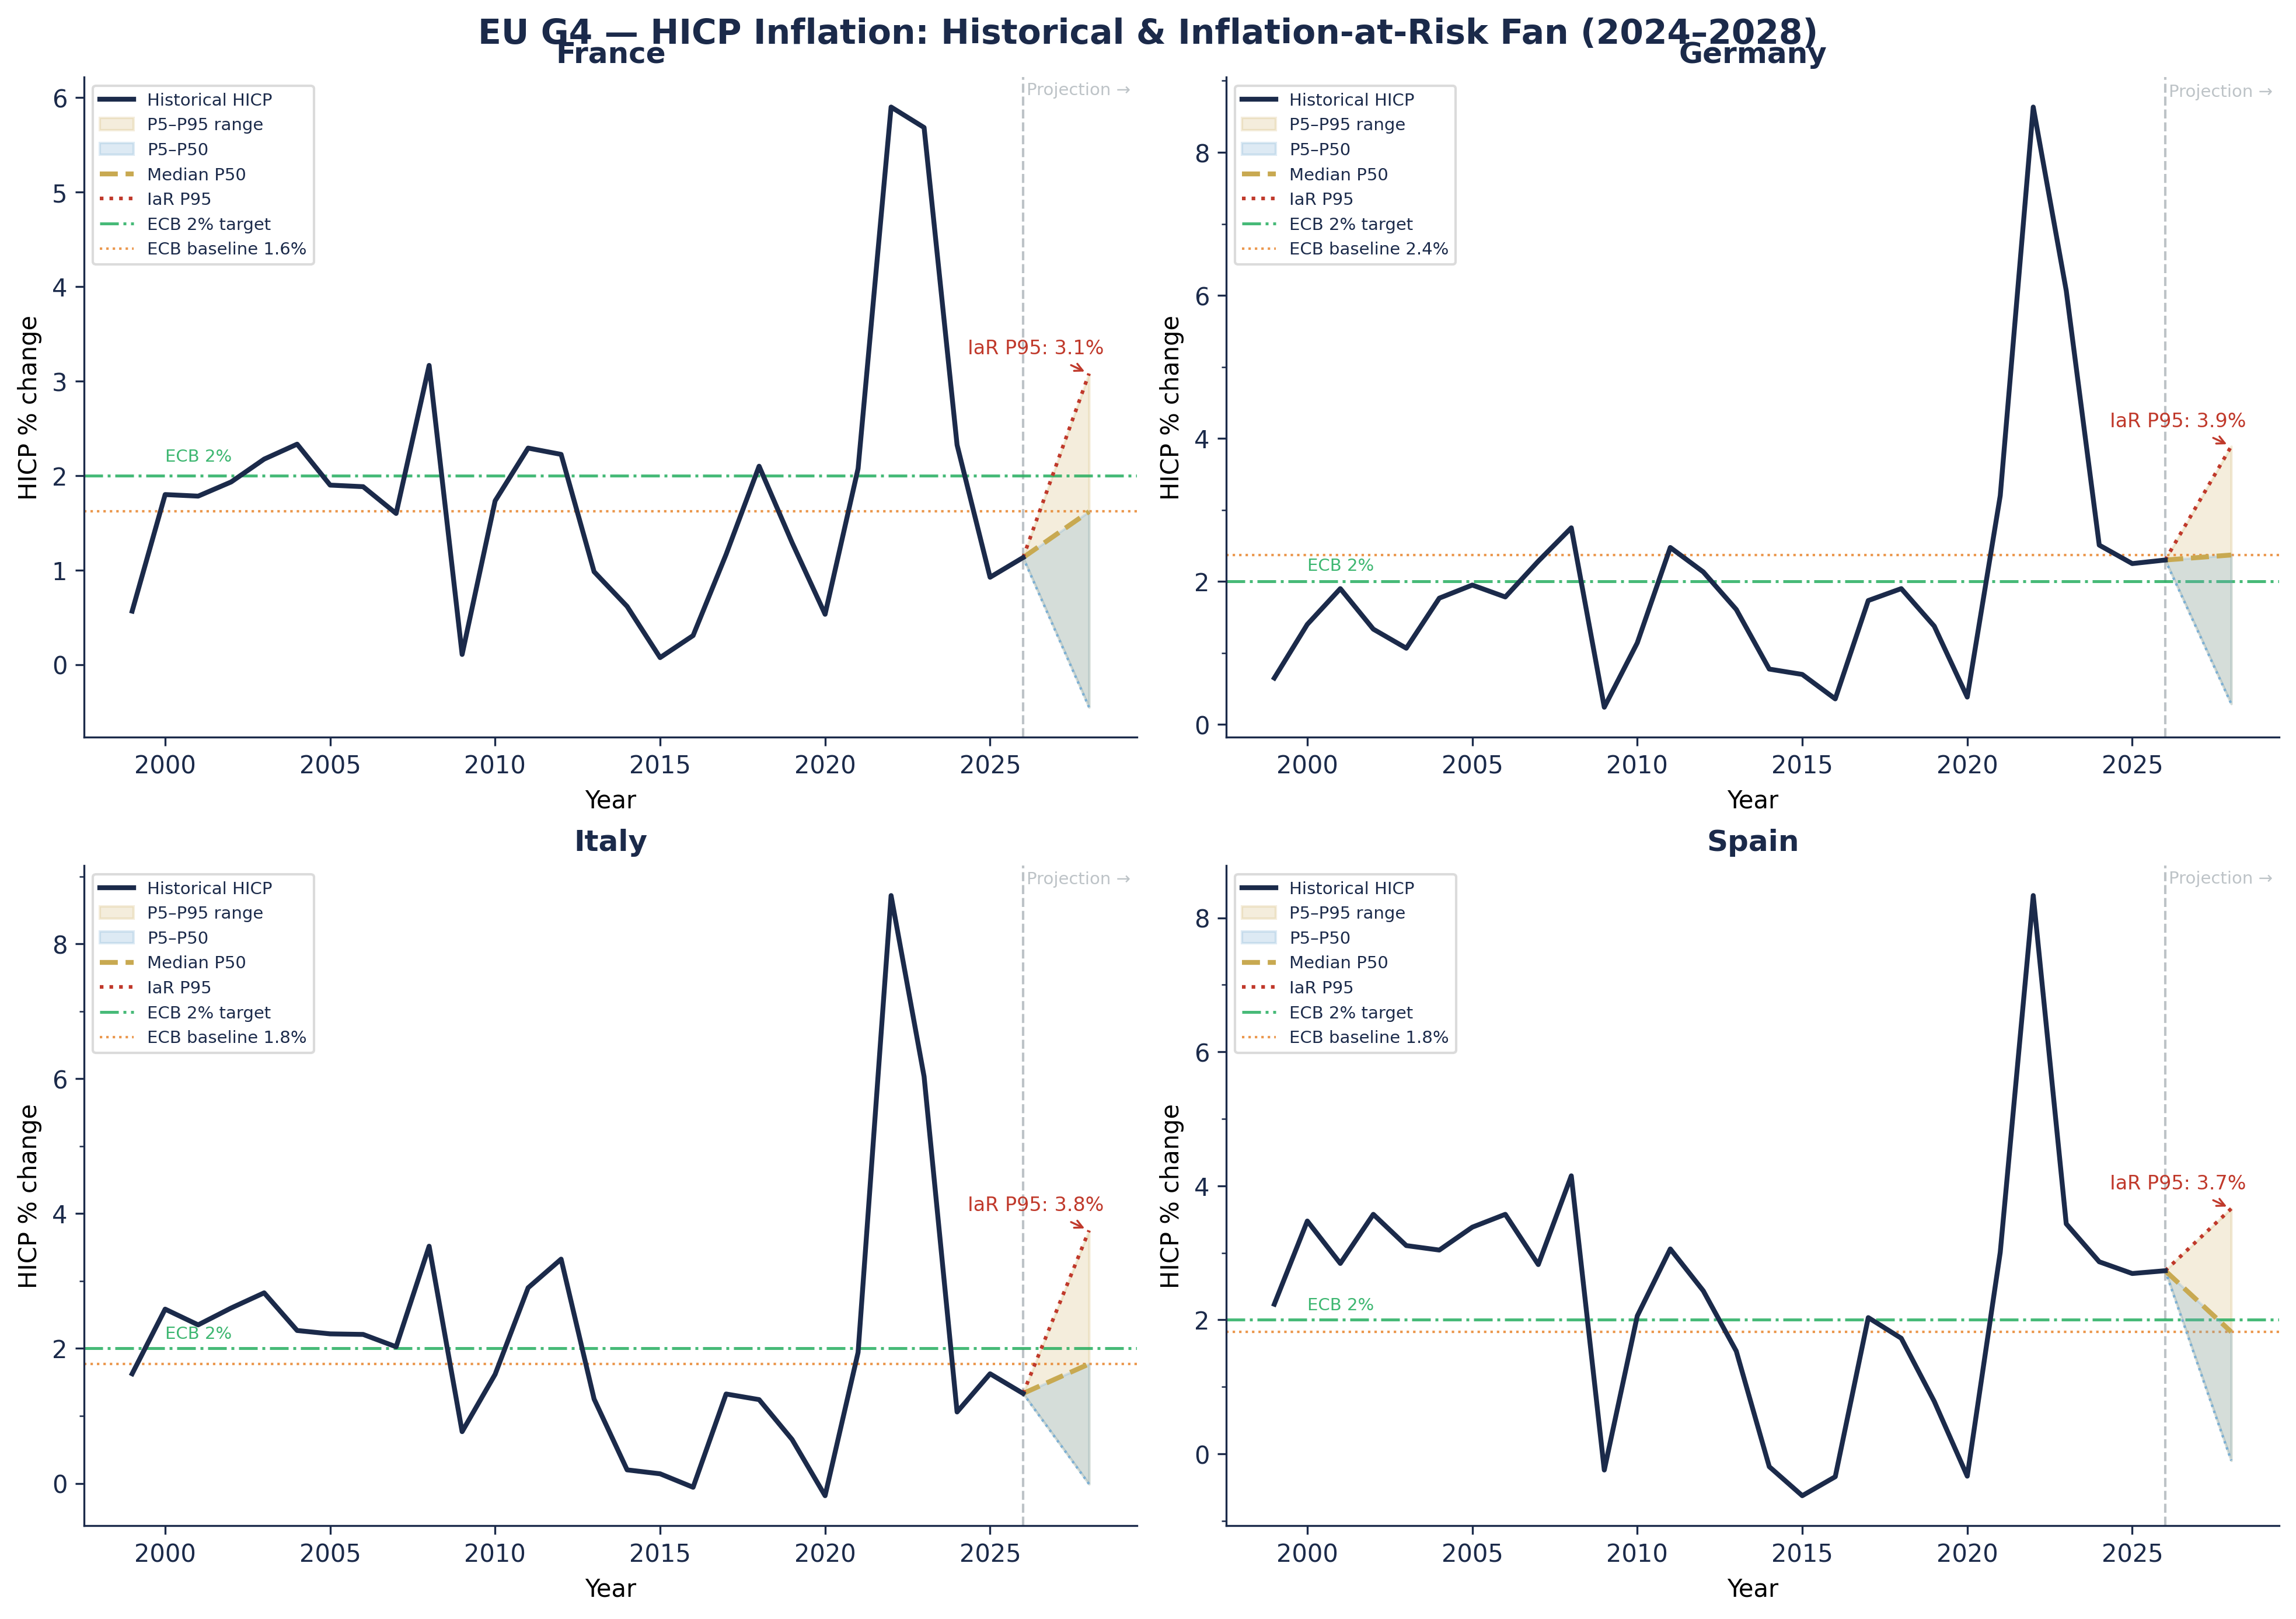

In [81]:
# ── Chart 1: Fan charts ──────────────────────────────────────────────────────
display(Image(str(chart_paths['fan'])))

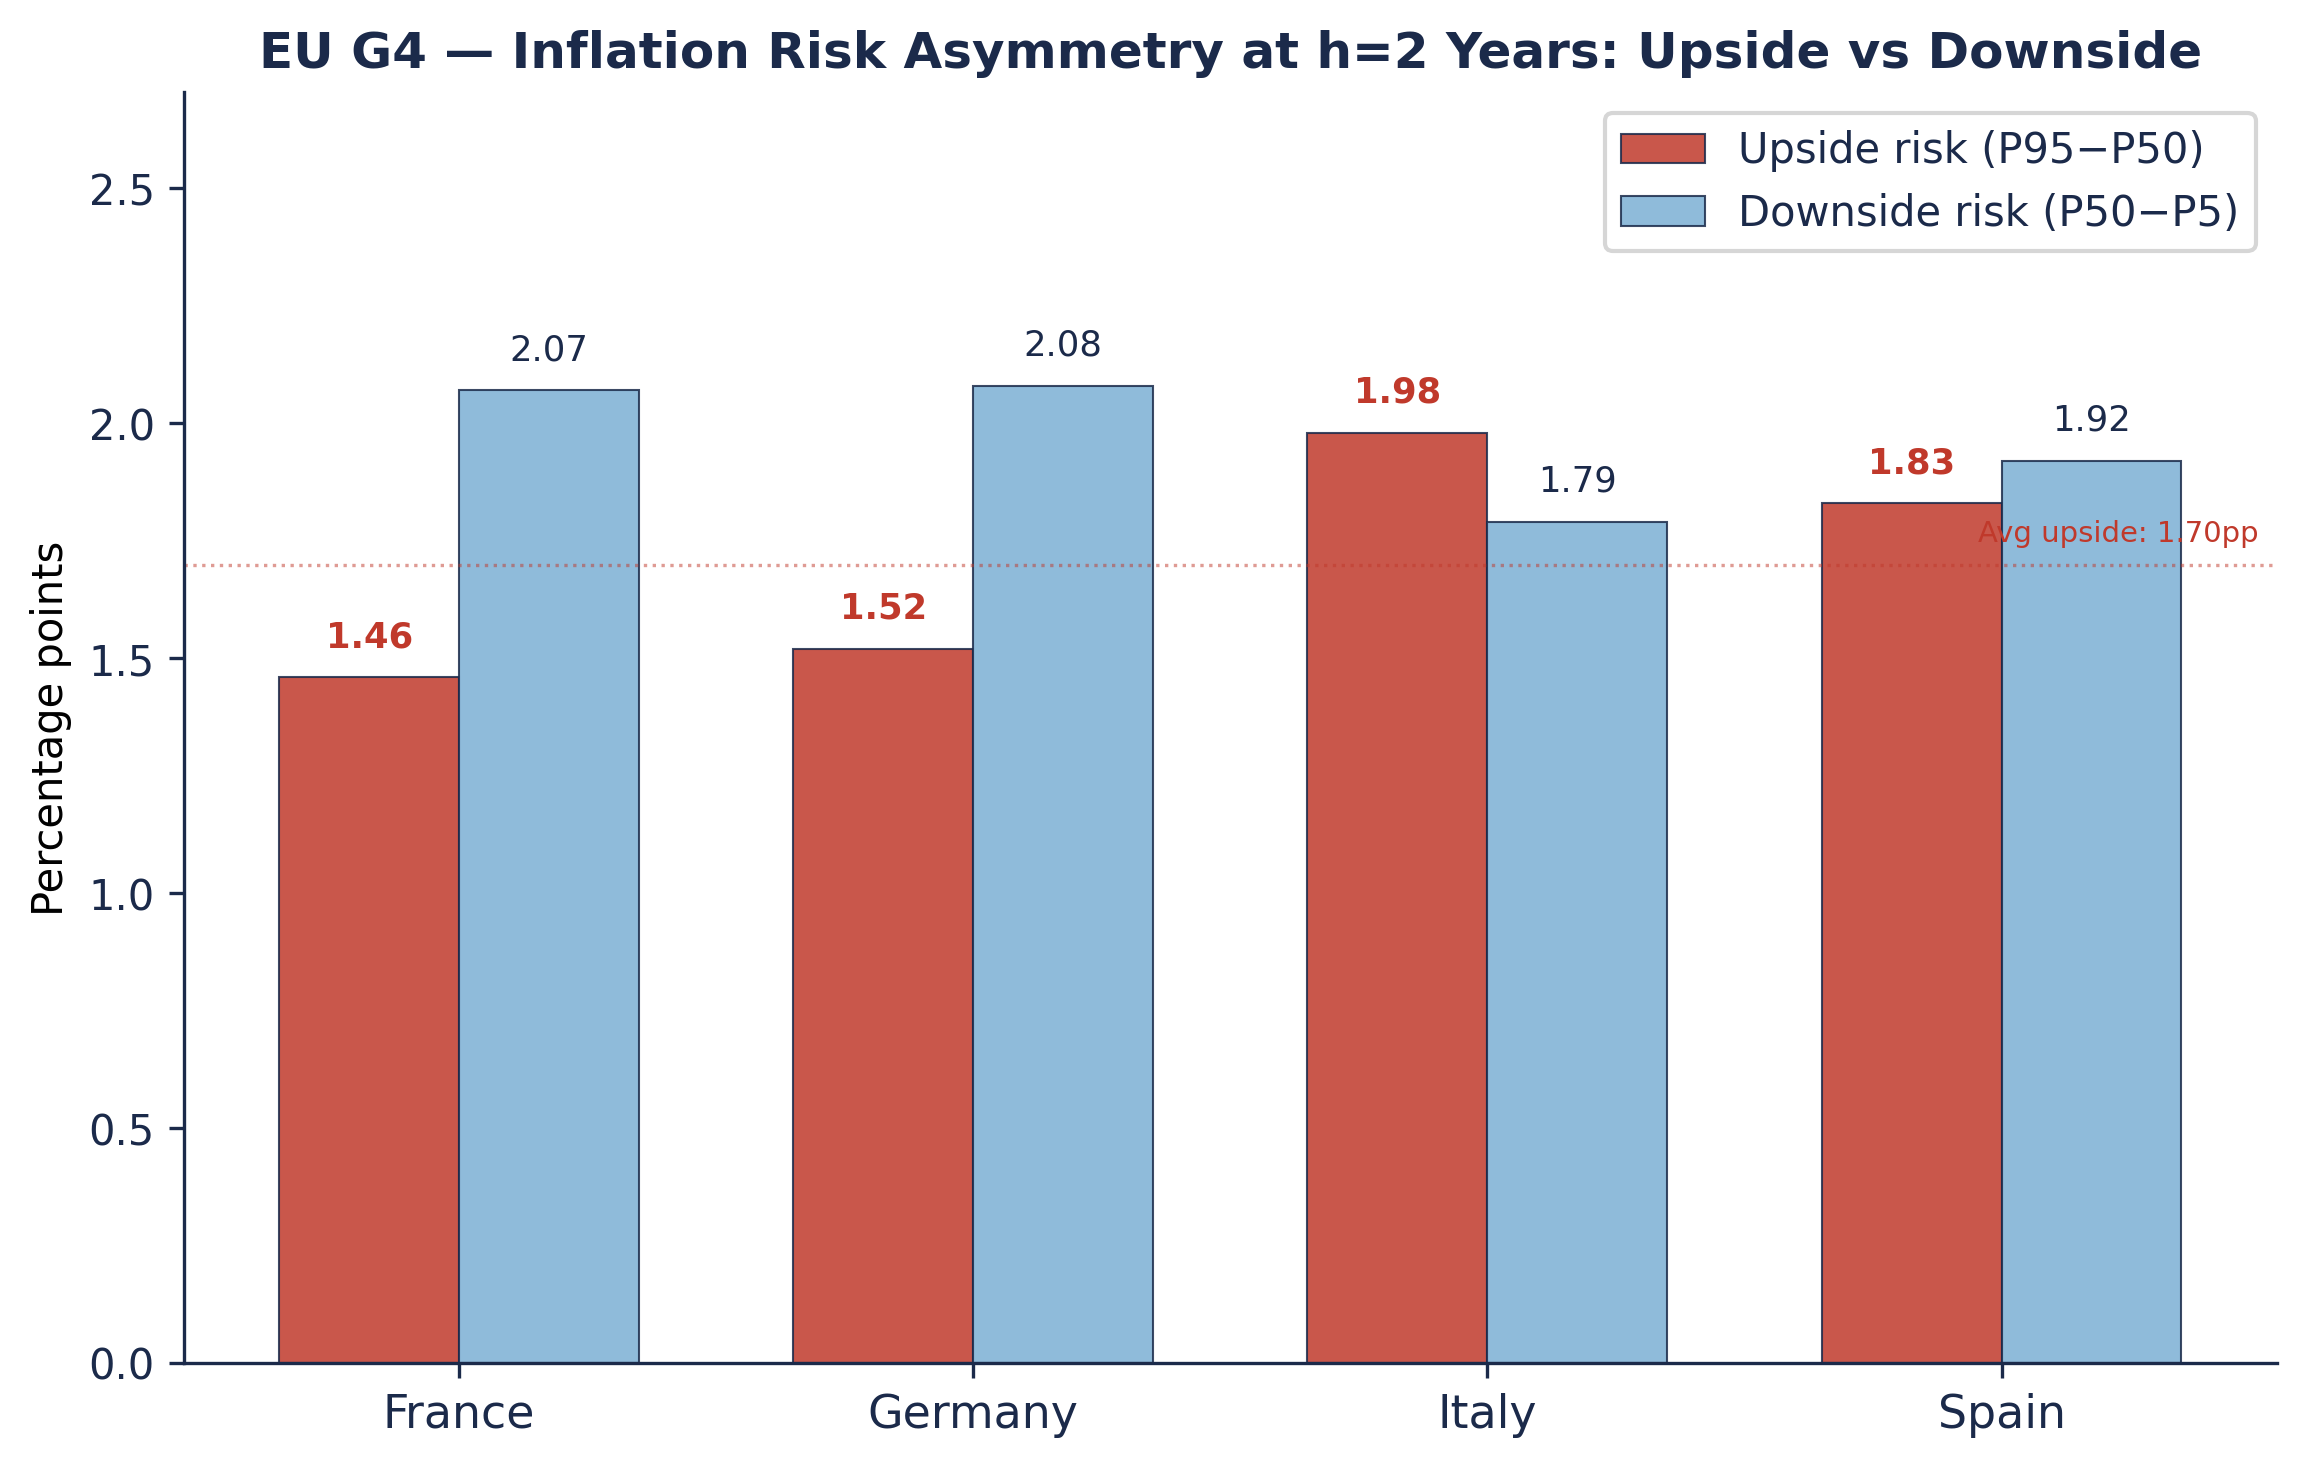

In [82]:
# ── Chart 2: Asymmetry bar ───────────────────────────────────────────────────
display(Image(str(chart_paths['asymmetry'])))

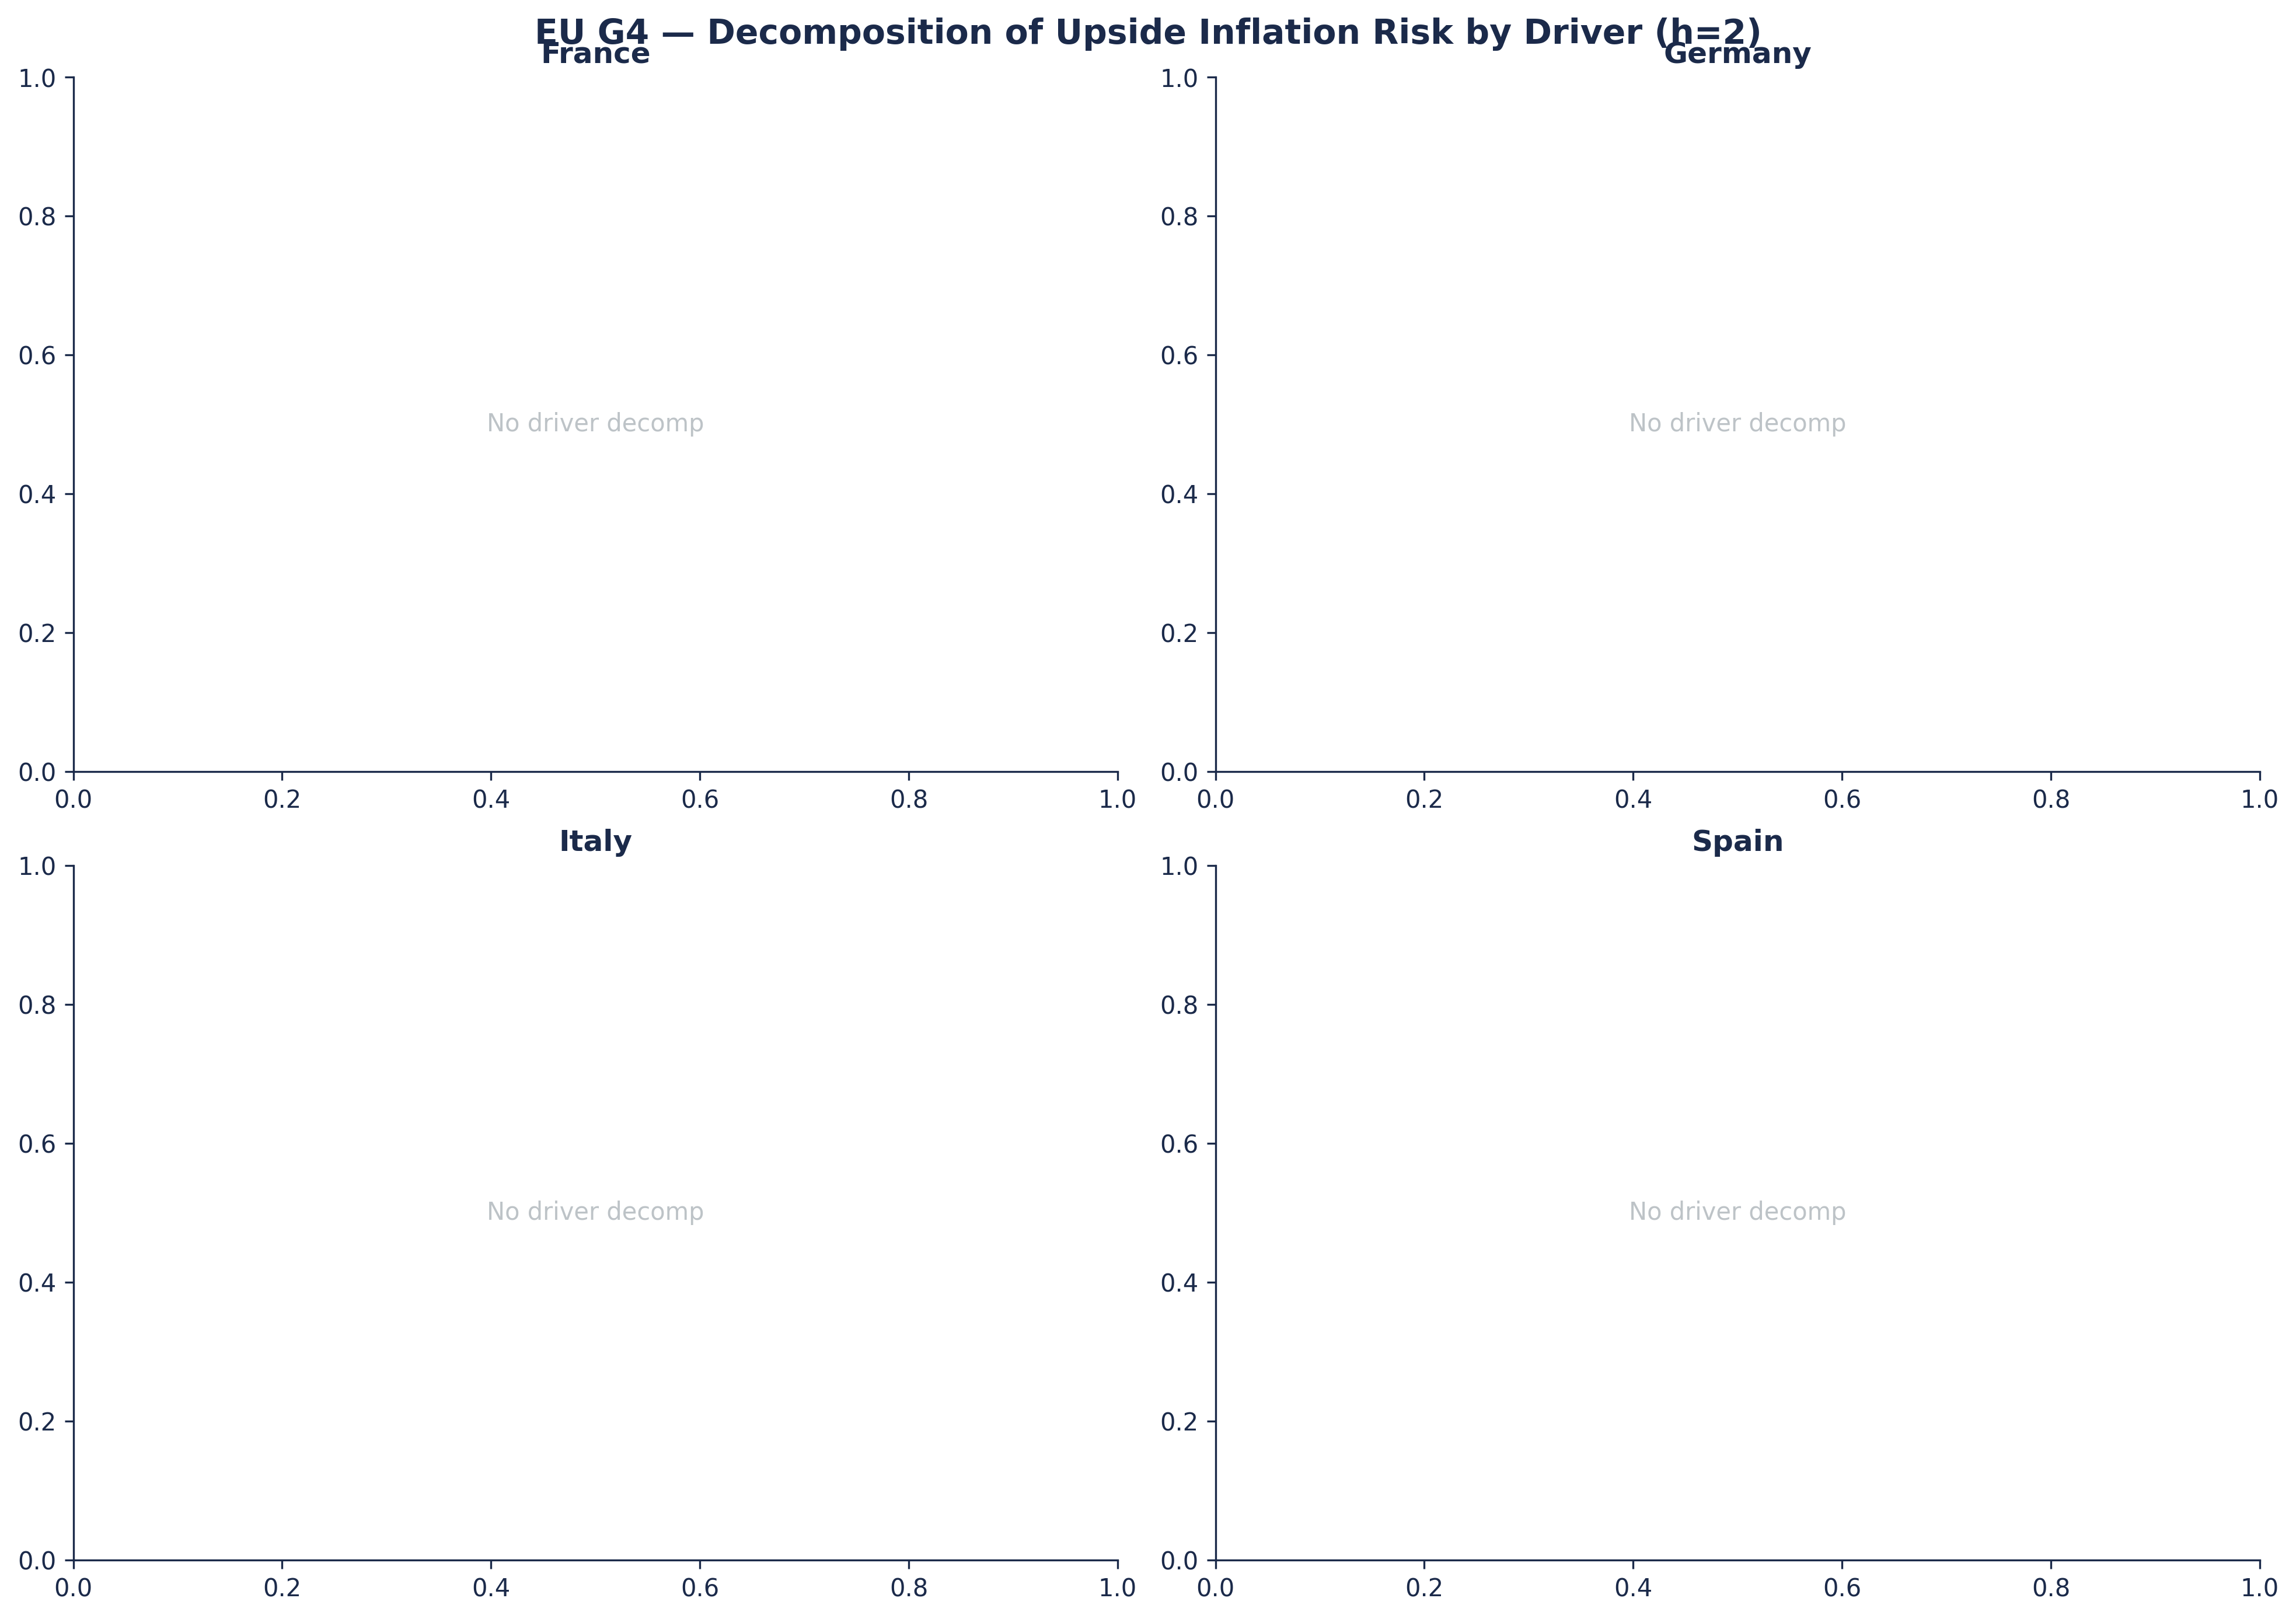

In [83]:
# ── Chart 3: Waterfall decomposition ────────────────────────────────────────
display(Image(str(chart_paths['waterfall'])))

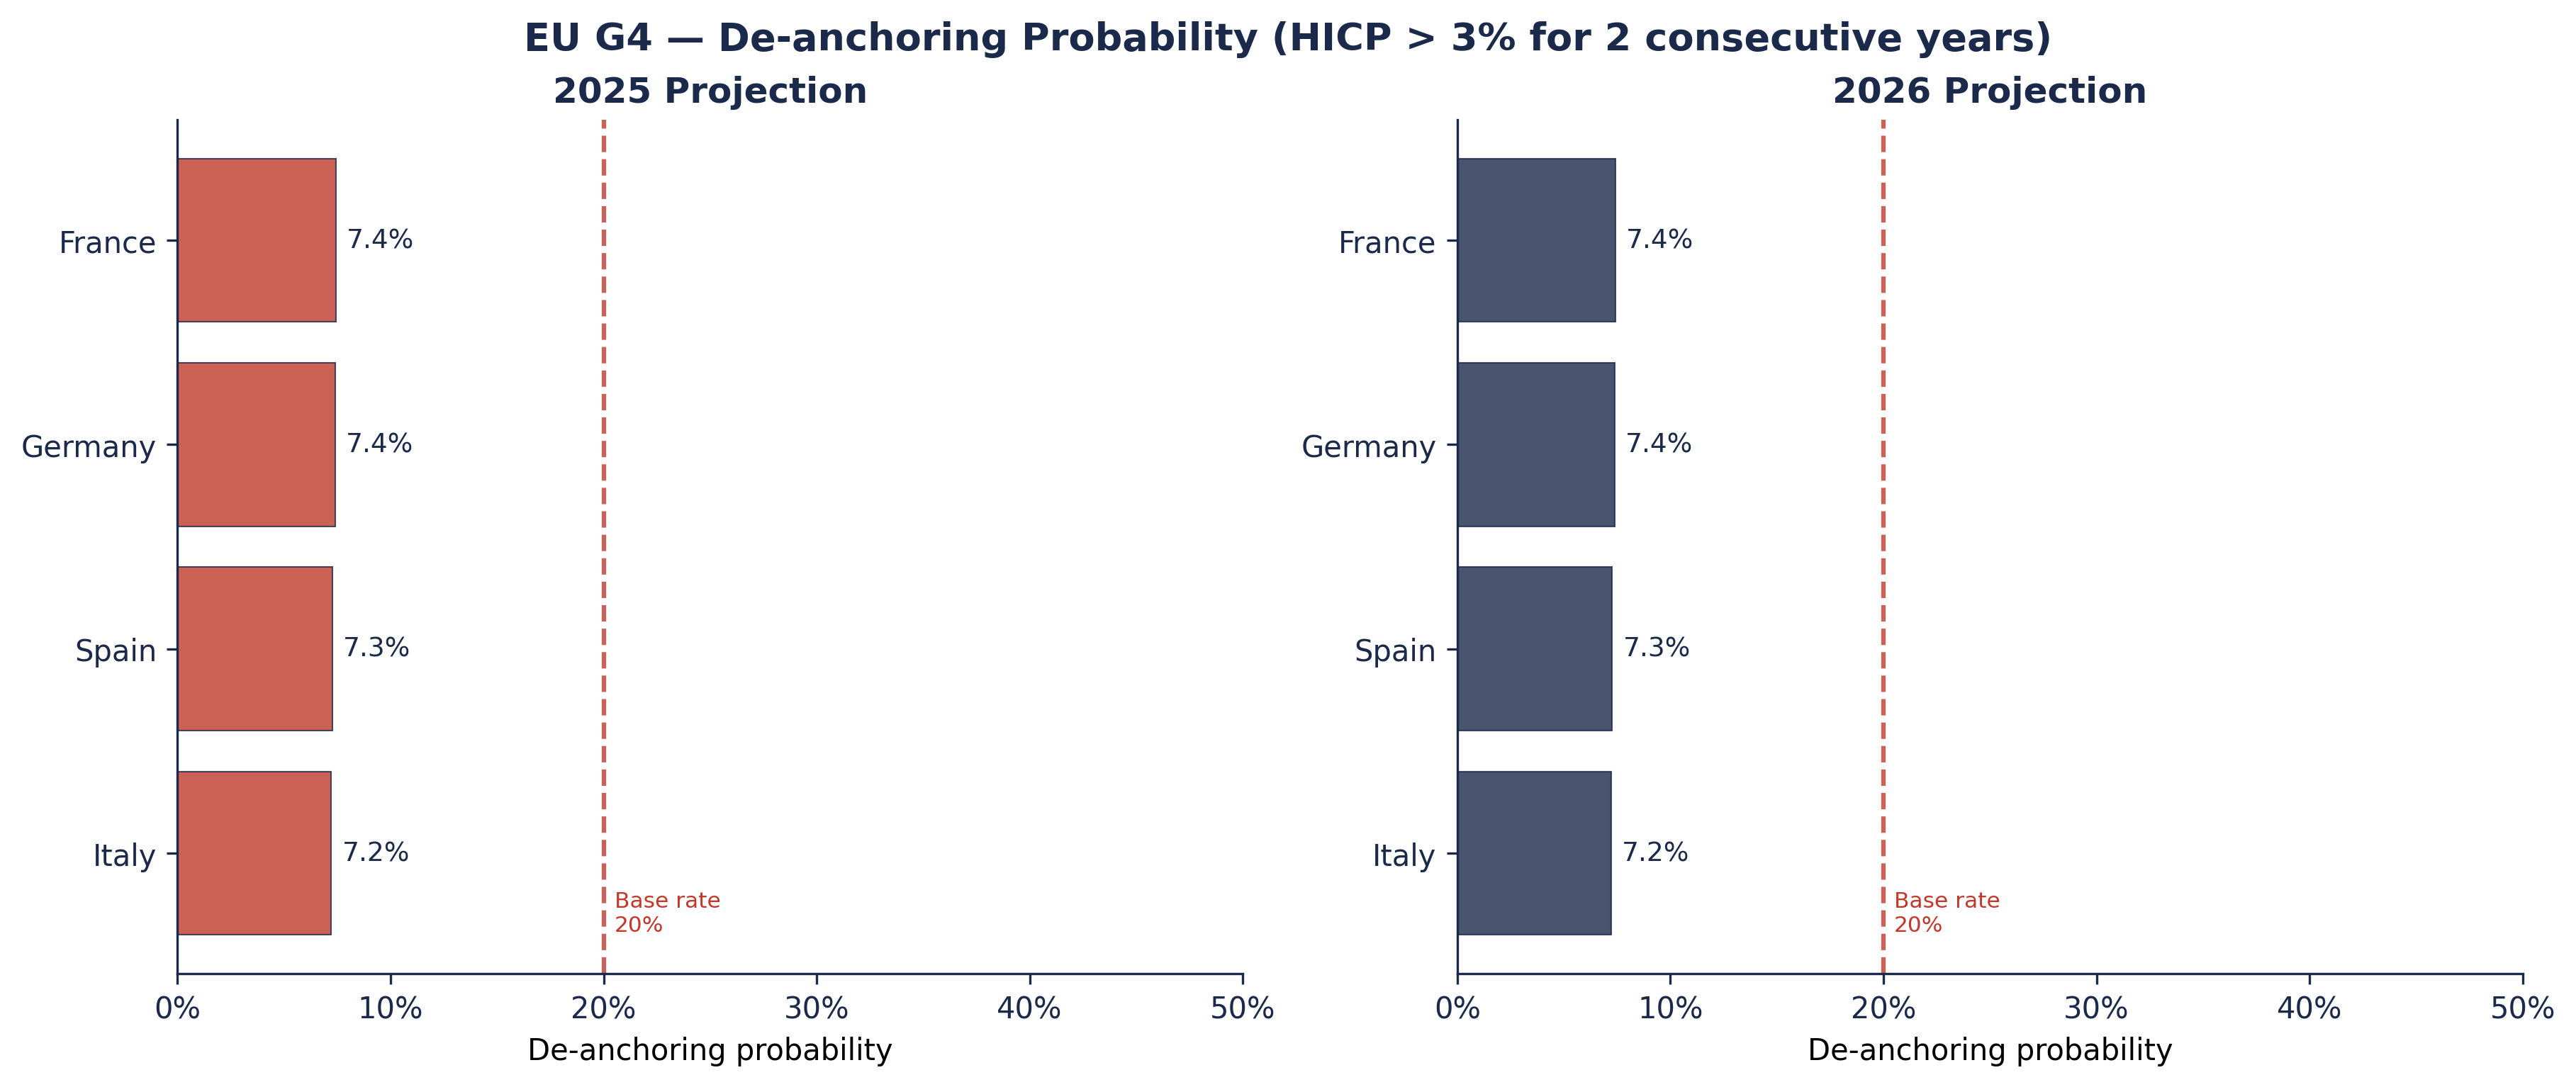

In [84]:
# ── Chart 4: De-anchoring signal ────────────────────────────────────────────
display(Image(str(chart_paths['deanchoring'])))

---
## Summary Results Table

In [85]:
# Build final summary table
summary_rows = []
for iso3 in G4:
    row   = iar[iar['iso3'] == iso3].iloc[0]
    p2025 = pooled_scores[(pooled_scores['iso3']==iso3) & (pooled_scores['year']==2025)]
    p2026 = pooled_scores[(pooled_scores['iso3']==iso3) & (pooled_scores['year']==2026)]
    summary_rows.append({
        'Country':          G4_LABELS[iso3],
        'ECB baseline 2027':f"{row['ecb_baseline']:.1f}%",
        'P50 (median)':     f"{row['Q50']:.2f}%",
        'IaR P95':          f"{row['IaR']:.2f}%",
        'Upside (pp)':      f"{row['Upside']:.2f}",
        'Downside (pp)':    f"{row['Downside']:.2f}",
        'P(deanchor) 2025': f"{p2025['pooled_prob'].values[0]:.1%}" if not p2025.empty else 'n/a',
        'P(deanchor) 2026': f"{p2026['pooled_prob'].values[0]:.1%}" if not p2026.empty else 'n/a',
    })

summary = pd.DataFrame(summary_rows).set_index('Country')
display(Markdown('### EU G4 Inflation-at-Risk — Final Summary Table (h = 2 years)'))
display(summary)

### EU G4 Inflation-at-Risk — Final Summary Table (h = 2 years)

,ECB baseline 2027,P50 (median),IaR P95,Upside (pp),Downside (pp),P(deanchor) 2025,P(deanchor) 2026
Country,,,,,,,
France,1.6%,1.62%,3.08%,1.46,2.07,7.4%,7.4%
Germany,2.4%,2.37%,3.89%,1.52,2.08,7.4%,7.4%
Italy,1.8%,1.77%,3.75%,1.98,1.79,7.2%,7.2%
Spain,1.8%,1.82%,3.66%,1.83,1.92,7.3%,7.3%


In [86]:
display(Markdown('''
---
**Interpretation guide:**
- **ECB baseline 2027**: Country-specific inflation forecast from EC AMECO (ZCPIH variable).
- **P50 (median)**: Model conditional median for the 2-year forward HICP rolling mean.
- **IaR P95**: 95th percentile of the conditional HICP distribution — the inflation-at-risk metric.
  By construction, IaR > ECB baseline > P05.
- **Upside (pp)**: P95 − P50 — the wideness of the *upside* tail.
- **Downside (pp)**: P50 − P05 — the wideness of the *downside* tail.
- **P(deanchor)**: Probability that HICP exceeds 3% for 2 consecutive years, from the panel logit.
  Historical base rate ≈ 20% of estimation sample.

*Model: Machado–Santos Silva (2019) three-step location-scale estimator;  
distribution: Fernández–Steel skewed-t;  
pooling: log-score weights across horizons h = {1, 2, 4};  
estimation panel: 29 EU/EEA countries, 1999–2025.*
'''))


---
**Interpretation guide:**
- **ECB baseline 2027**: Country-specific inflation forecast from EC AMECO (ZCPIH variable).
- **P50 (median)**: Model conditional median for the 2-year forward HICP rolling mean.
- **IaR P95**: 95th percentile of the conditional HICP distribution — the inflation-at-risk metric.
  By construction, IaR > ECB baseline > P05.
- **Upside (pp)**: P95 − P50 — the wideness of the *upside* tail.
- **Downside (pp)**: P50 − P05 — the wideness of the *downside* tail.
- **P(deanchor)**: Probability that HICP exceeds 3% for 2 consecutive years, from the panel logit.
  Historical base rate ≈ 20% of estimation sample.

*Model: Machado–Santos Silva (2019) three-step location-scale estimator;  
distribution: Fernández–Steel skewed-t;  
pooling: log-score weights across horizons h = {1, 2, 4};  
estimation panel: 29 EU/EEA countries, 1999–2025.*
